In [6]:
import sys
sys.path.append('../../newpkpo')
sys.path.append('../local_modules')
import pyFAI
import dill
import numpy as np
from model import PeakPoModel
from xrd_unitconv import *
import quick_plots as quick # A function to plot XRD pattern
import fancy_plots_update as fancy # A function to plot XRD pattern
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [7]:
def generate_model(dpp_fl):
    with open(dpp_fl, 'rb') as f:
        model_dpp_fl = dill.load(f)
    model_dpp_fl.__dict__
    model_fl = PeakPoModel()
    model_fl.set_from(model_dpp_fl, new_chi_path = '../data')
    return model_fl

In [8]:
mgfesi_1 = '../../../ALS-1-2023/Xuehui/Cell-34/highP/longexposure/MFS#108  0001.dpp'
model_mgfesi_1 =  generate_model(mgfesi_1)

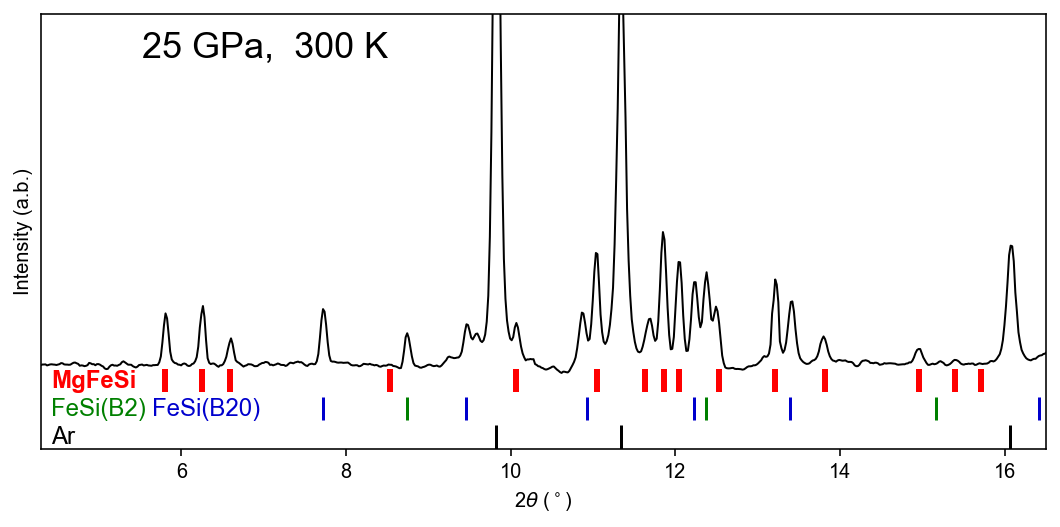

In [9]:
c_phase= {'MgFeSi':'r', 'FeSi(B2)': 'g', 'FeSi(B20)': 'mediumblue', 'Ar':'k'}

f, ax = plt.subplots(figsize=(9,4))# dpi = 300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 20
fancy.plot_diffpattern(ax, model_mgfesi_1)
ax.set_xlim(4.3, 16.5)
ax.set_ylim(0, 200)
fancy.plot_jcpds(ax, model_mgfesi_1, colors = [c_phase['MgFeSi'], c_phase['FeSi(B2)'], c_phase['FeSi(B20)'], c_phase['Ar']], 
                 fontsize = 12, bar_position=0.01, bar_height=0.4, bar_thick=1.5, 
           show_index=False, phase_names = ['MgFeSi', 'FeSi(B2)','FeSi(B20)','Ar'], 
                 bar_vsep=1.2, roi_phase = [0], roi_lw = 3,grouped_phases=[[1, 2]], phase_label_show = 'all')
                #roi_phase = ['Ar'], roi_lw = 4)#'Mg$_2$MgH$_6$'


pressure = model_mgfesi_1.get_saved_pressure()
temperature =model_mgfesi_1.get_saved_temperature()
ax.text(0.10,0.9, "{0:.0f} GPa, {1: .0f} K".format(pressure, temperature), 
        transform = ax.transAxes, fontsize=18)
ax.set_xlabel(r'2$\theta$ ($^\circ$)')
ax.set_ylabel('Intensity (a.b.)')
plt.show()